# Bank Marketing Campaign Prediction

The project name is "Bank Marketing Campaign Prediction Machine Learning Project" which focuses on analysis customers data from Portugal Banking company to identify variables that influence customers to subscribe to bank term deposit..

GitHub Repository: https://github.com/waleedkhanak19-cloud/intro--to--AI-and-ML

**Problem Statement**

Marketing campaigns are significant for the advertising of the banking products, but it may be expensive and ineffective to reach out the whole customer base.This project is to create a classification model of machine learning to predict the customers who are willing to be the subscribers.

*Why is this problem important?*

- Contacting customers without any prioritisation is slow and expensive, and only about one call in nine in this dataset ends in a subscription.
- Machine learning can pick up patterns in past campaigns that are hard to see manually, such as the combined effect of economic conditions and a customer's previous contact history.
- A dependable prediction lets the bank rank its customer list and spend its call budget where the chance of success is highest.

*How will solving this problem benefit the company?*

- **Lower campaign cost:** fewer calls are made to customers who are very unlikely to subscribe.
- **Evidence-based planning:** marketing managers can base targeting decisions on the results of previous campaigns instead of intuition.
- **Better customer experience:** uninterested customers receive fewer unwanted calls, and offers can be adapted to the groups that respond best.

*How would you collect relevant data?*

source: https://archive.ics.uci.edu/dataset/222/bank+marketing 

## Data Loading and Overview


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report,ConfusionMatrixDisplay, RocCurveDisplay)



In [5]:
DATA_PATH = r"D:\GISMA-MS DSAIBI\ML_Project\bank-full.csv"   
campaign_df = pd.read_csv(DATA_PATH, sep=";")
campaign_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
campaign_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [7]:
quality_check = pd.DataFrame({
    "null_values": campaign_df.isna().sum(),
    "unknown_labels": (campaign_df == "unknown").sum(),
})
print("Duplicate rows:", campaign_df.duplicated().sum())
quality_check[quality_check.sum(axis=1) > 0]

Duplicate rows: 12


,null_values,unknown_labels
job,0,330
marital,0,80
education,0,1731
default,0,8597
housing,0,990
loan,0,990


## Exploratory Data Analysis

### Target Variable

In [8]:
campaign_df["y"] = (campaign_df["y"] == "yes").astype(int)

target_summary = campaign_df["y"].value_counts().rename_axis("subscribed").to_frame("customers")
target_summary

,customers
subscribed,
0,36548
1,4640


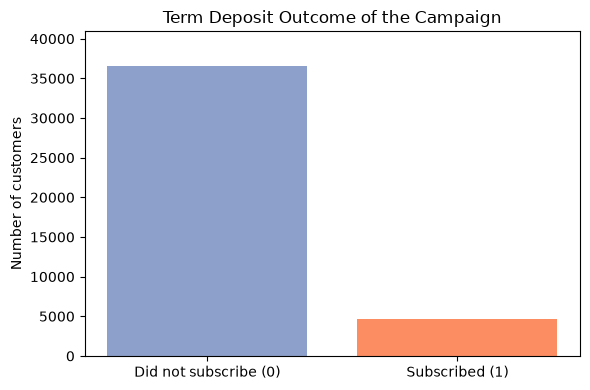

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Did not subscribe (0)", "Subscribed (1)"], target_summary["customers"],
            color=["#8da0cb", "#fc8d62"])
ax.set_title("Term Deposit Outcome of the Campaign")
ax.set_ylabel("Number of customers")
ax.set_ylim(0, target_summary["customers"].max() * 1.12)
plt.tight_layout()
plt.show()

**Observation:** the bar chart shows the distribution of subscribers and non-subscribers.

### Categorical Features



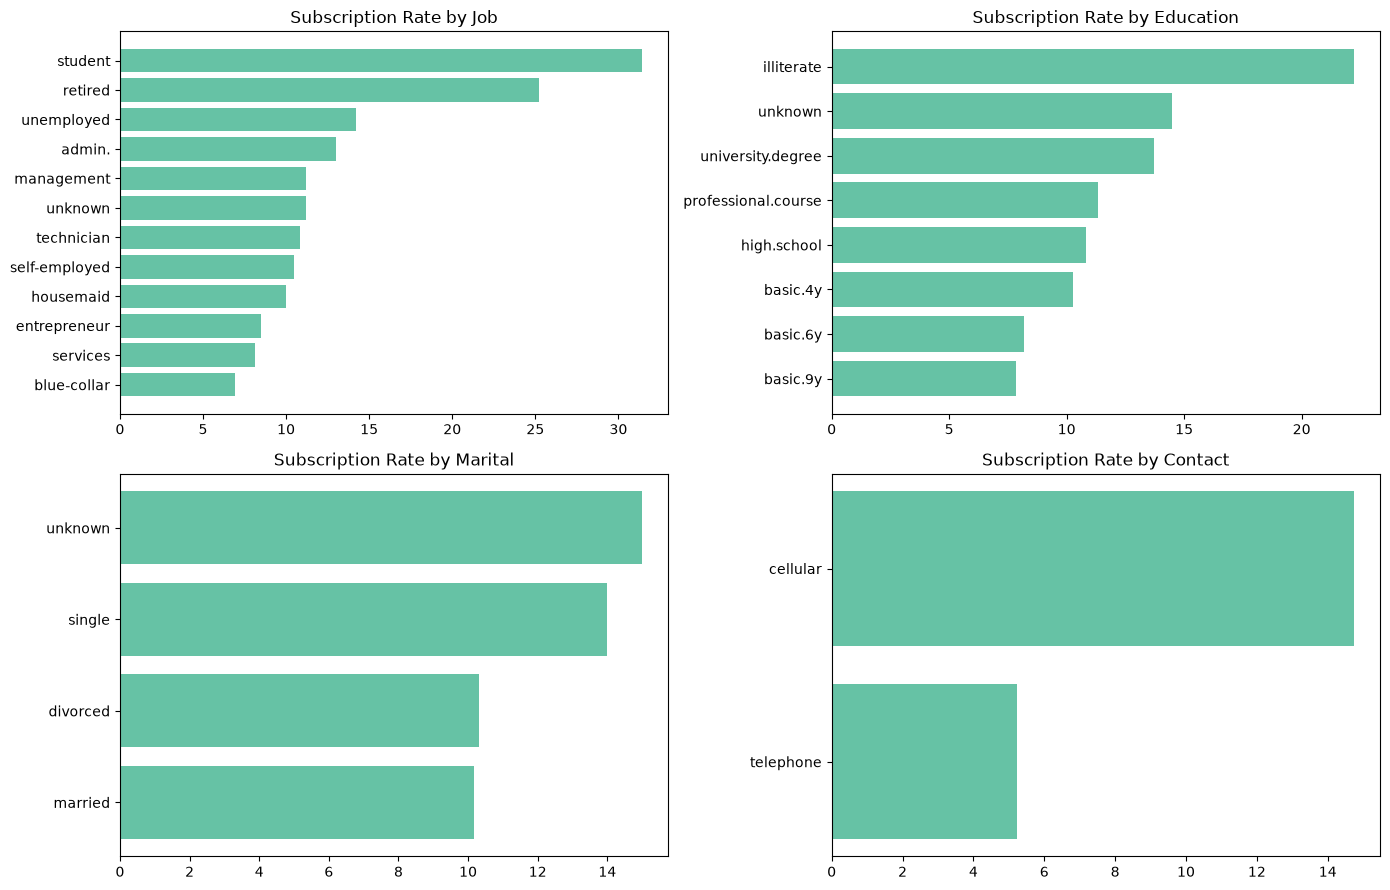

In [10]:
overall_rate = campaign_df["y"].mean()
cat_to_plot = ["job", "education", "marital", "contact"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cat_to_plot):
    rates = campaign_df.groupby(col)["y"].mean().sort_values() * 100
    ax.barh(rates.index, rates.values, color="#66c2a5")
    ax.set_title(f"Subscription Rate by {col.title()}")
plt.tight_layout()
plt.show()

**Observations:** this shows the impact of categorical features on subscription rate.

### Correlation Heatmap

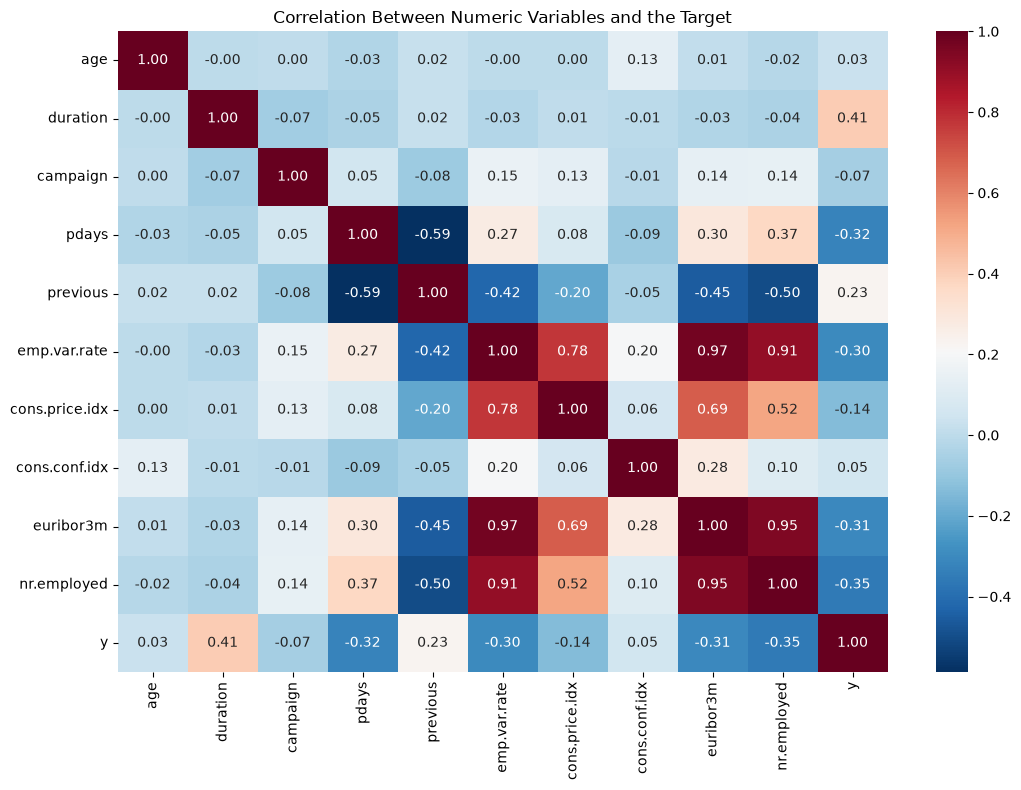

In [11]:
numeric_corr = campaign_df.select_dtypes(include="number").corr()
plt.figure(figsize=(11, 8))
sns.heatmap(numeric_corr,annot=True, fmt=".2f",
            cmap="RdBu_r")
plt.title("Correlation Between Numeric Variables and the Target")
plt.tight_layout()
plt.show()

**Observation:** The correlation heatmap shows the relationships between numerical variables in the bank marketing dataset.Most variables have weak to strong correlations, indicating they provide relatively unique information.


## Data Preparation and Splitting

In [14]:
modelling_df = campaign_df.drop_duplicates().drop(columns="duration")
features = modelling_df.drop(columns="y")
target = modelling_df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, stratify=target, random_state=42
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("numeric", Pipeline([
        ("fill", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("fill", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

print("Train set:", X_train.shape, "| Test set:", X_test.shape)


Train set: (32940, 19) | Test set: (8236, 19)


**Observation:** the duration variable was removed because it is only known after the customer has been contacted. it can cause data linkage. also the data was divided into train (80%) and test(20%).

## Model Training



### Random Forest

In [15]:
rf_model = Pipeline([
    ("prep", clone(preprocess)),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
                                    class_weight="balanced", random_state=42, n_jobs=-1)),
])
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

### Gradient Boosting

In [16]:
gb_model = Pipeline([
    ("prep", clone(preprocess)),
    ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3,
                                        subsample=0.8, random_state=42)),
])
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

### Model Evaluation



In [26]:
def score_model(name, model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Precision": precision_score(y, pred),
        "Recall": recall_score(y, pred),
        "F1": f1_score(y, pred),
        "ROC-AUC": roc_auc_score(y, proba),
    }

baseline_models = {"Random Forest": rf_model, "Gradient Boosting": gb_model}
baseline_scores = (pd.DataFrame([score_model(n, m, X_test, y_test) for n, m in baseline_models.items()])
                .set_index("Model").round(2))
baseline_scores

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.86,0.42,0.64,0.50,0.81
Gradient Boosting,0.90,0.66,0.23,0.34,0.81


**Observation:** Gradient Boosting has the maximum accuracy,precision but low recall.Random Forest has the highest F1 score and impressively high recall.Thus,choosing a model should be based on business goals, not just on accuracy.


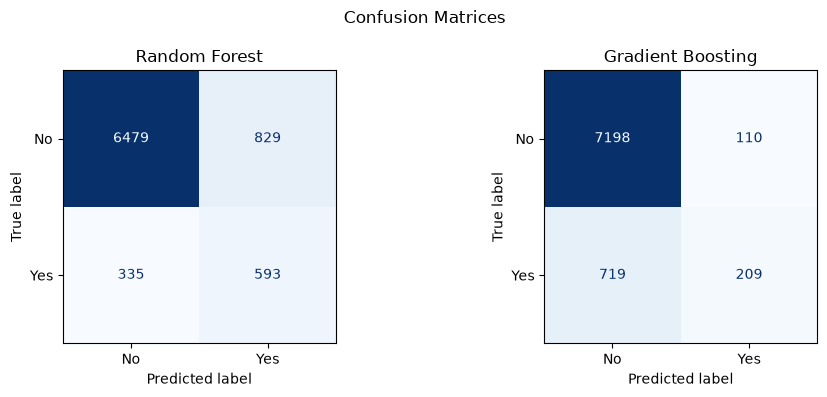

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, baseline_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["No", "Yes"],
                                        cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
fig.suptitle("Confusion Matrices")
plt.tight_layout()
plt.show()

**Observation:** 
Random Forest therefore makes more false positive errors, while Gradient Boosting makes far more True positive errors. This shows that the class imbalance has to be handled during tuning, particularly for Gradient Boosting.

## Hyperparameter Tuning

In [27]:
rf_search = GridSearchCV(
    Pipeline([("prep", clone(preprocess)),
            ("model", RandomForestClassifier(random_state=42, n_jobs=1))]),
    param_grid={
        "model__n_estimators": [200, 400],
        "model__max_depth": [10, 20],
        "model__min_samples_leaf": [1, 5],
    },
    scoring="f1", cv=3, n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print("Best Random Forest parameters:", rf_search.best_params_)


Best Random Forest parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


In [28]:
gb_search = GridSearchCV(
    Pipeline([("prep", clone(preprocess)),
            ("model", GradientBoostingClassifier(subsample=0.8, random_state=42))]),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3, 4],
    },
    scoring="f1", cv=3, n_jobs=-1,
)
gb_search.fit(X_train, y_train)
print("Best Gradient Boosting parameters:", gb_search.best_params_)


Best Gradient Boosting parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}


In [29]:
tuned_models = {
    "RF (tuned)": rf_search.best_estimator_,
    "GB (tuned)": gb_search.best_estimator_,
}
tuned_scores = (pd.DataFrame([score_model(n, m, X_test, y_test) for n, m in tuned_models.items()])
                .set_index("Model").round(3))



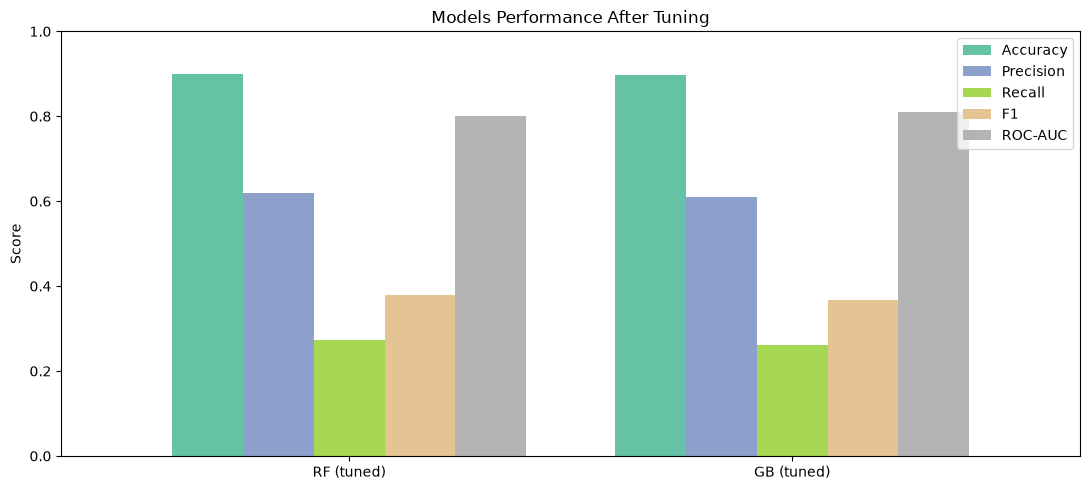

In [30]:
ax = tuned_scores.plot(kind="bar", figsize=(11, 5), width=0.8, colormap="Set2")
ax.set_title("Models Performance After Tuning")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** After hyperparameter tuning randomForest has still being the best model to choose as its Precision,f1score are higher than gradient boosting model.


## ROC Curve

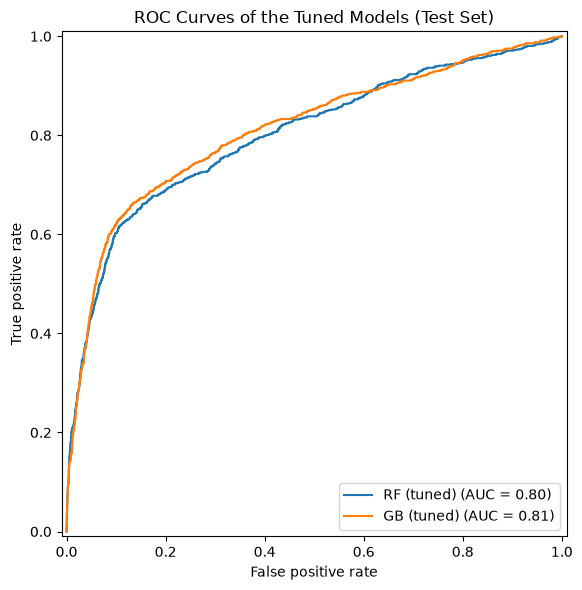

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.set_title("ROC Curves of the Tuned Models (Test Set)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observation:** the tuned models shows that RF has perfectly define subscriber from non-subscribers
and RF AUC is 80% and GB AUC is 81%

## Final Model



In [33]:
final_name = tuned_scores["F1"].idxmax()
final_model = tuned_models[final_name]
final_pred = final_model.predict(X_test)

print("Selected model:", final_name, "\n")
print(classification_report(y_test, final_pred, target_names=["No", "Yes"], digits=2))

Selected model: RF (tuned) 

              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7308
         Yes       0.62      0.27      0.38       928

    accuracy                           0.90      8236
   macro avg       0.77      0.63      0.66      8236
weighted avg       0.88      0.90      0.88      8236



**Observation:** RF tuned as been choosen as the best model as its F1 score is higher than other model.

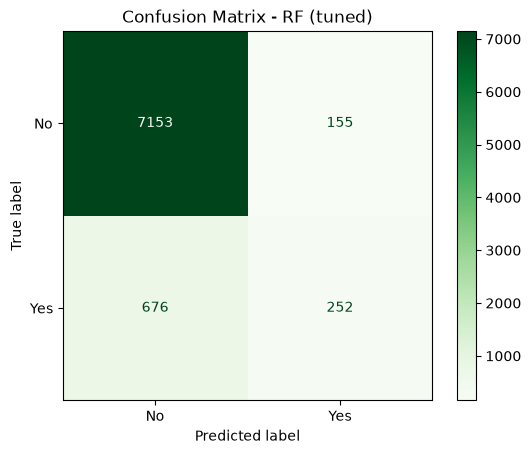

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=["No", "Yes"], cmap="Greens")
plt.title(f"Confusion Matrix - {final_name}")
plt.grid(False)
plt.show()

## Conclusion
This project built a machine learning pipeline that predicts whether a bank customer will subscribe to a term deposit.By using only information available before the call is made. After the data was checked, duplicates were removed and the leaking `duration` variable was dropped, Random Forest and Gradient Boosting models were trained. The analysis also showed that accuracy is misleading on an imbalanced dataset.

## References
- Breiman, L. (2001) 'Random forests', *Machine Learning*, 45(1), pp. 5–32. Available at: https://doi.org/10.1023/A:1010933404324

- Friedman, J.H. (2001) 'Greedy function approximation: a gradient boosting machine', *The Annals of Statistics*, 29(5), pp. 1189–1232. Available at: https://doi.org/10.1214/aos/1013203451

- Hunter, J.D. (2007) 'Matplotlib: a 2D graphics environment', *Computing in Science & Engineering*, 9(3), pp. 90–95. Available at: https://doi.org/10.1109/MCSE.2007.55

- Moro, S., Cortez, P. and Rita, P. (2014) 'A data-driven approach to predict the success of bank telemarketing', *Decision Support Systems*, 62, pp. 22–31. Available at: https://doi.org/10.1016/j.dss.2014.03.001

- Moro, S., Rita, P. and Cortez, P. (2014) *Bank Marketing* [Dataset]. UCI Machine Learning Repository. Available at: https://archive.ics.uci.edu/dataset/222/bank+marketing

- NumPy Developers (2026) *NumPy documentation*. Available at: https://numpy.org/doc/

- pandas development team (2026) *pandas documentation*. Available at: https://pandas.pydata.org/docs/

- Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830. Available at: https://jmlr.org/papers/v12/pedregosa11a.html

- Python Software Foundation (2026) *Python 3 documentation*. Available at: https://docs.python.org/3/

- scikit-learn developers (2026) *GridSearchCV*. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

- scikit-learn developers (2026) *Metrics and scoring: quantifying the quality of predictions*. Available at: https://scikit-learn.org/stable/modules/model_evaluation.html

- scikit-learn developers (2026) *Permutation feature importance*. Available at: https://scikit-learn.org/stable/modules/permutation_importance.html

- Waskom, M.L. (2021) 'seaborn: statistical data visualization', *Journal of Open Source Software*, 6(60), p. 3021. Available at: https://doi.org/10.21105/joss.03021

By WALEED ABUL KHAIR

GH1060565